### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
data = pd.read_csv("gaia_stars.csv")
print("inti shape", data.shape)
print("Loading Gaia stellar catalog...")
data = pd.read_csv('gaia_stars.csv')
print(f"Initial dataset shape: {data.shape}")
print("\nFirst 5 rows:")
display(data.head())

inti shape (73148, 12)
Loading Gaia stellar catalog...
Initial dataset shape: (73148, 12)

First 5 rows:


,ra,dec,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,radial_velocity,ruwe,teff_gspphot,phot_variable_flag
0,251.589977,-50.638635,13.398257,0.017850,13.470652,14.585335,12.419784,2.165551,12.315269,0.951887,3730.103,NOT_AVAILABLE
1,250.185079,-51.477674,19.588654,0.025484,6.224640,6.379528,5.939466,0.440062,45.425500,0.782458,7051.192,VARIABLE
2,250.772902,-51.598985,10.326266,0.020964,13.695807,14.826818,12.635778,2.191039,7.051061,1.033412,3796.808,NOT_AVAILABLE
3,317.395254,67.908576,11.136129,0.017837,14.756236,16.031088,13.637453,2.393635,-40.089650,1.133741,3564.809,NOT_AVAILABLE
4,295.130352,70.286247,17.357228,0.010188,10.476051,11.063625,9.755102,1.308523,1.091031,1.091369,4607.393,VARIABLE


In [4]:
print("missing vals", data.isnull().sum())

missing vals ra                       0
dec                      0
parallax                 0
parallax_error           0
phot_g_mean_mag          0
phot_bp_mean_mag         0
phot_rp_mean_mag         0
bp_rp                    0
radial_velocity       3030
ruwe                     0
teff_gspphot             0
phot_variable_flag       0
dtype: int64


In [ ]:
data = data.dropna(subset=['radial_velocity'])  
print("\nShape after dropping missing radial_velocity:", data.shape)


Shape after dropping missing radial_velocity: (70118, 12)


4. Calculate Derived Quantities

In [ ]:
data['distance_pc'] = 1000 / data['parallax']  # Only valid for parallax > 0
data = data[data['parallax'] > 0]  # Remove invalid parallax values

# Calculate absolute magnitude (M_G)
data['abs_mag'] = data['phot_g_mean_mag'] - 5 * np.log10(data['distance_pc']) + 5

# Filter high-parallax-error stars (keep errors < 20%)
data = data[(data['parallax_error'] / data['parallax']) < 0.2]

print("\nProcessed dataset shape:", data.shape)
display(data[['parallax', 'distance_pc', 'phot_g_mean_mag', 'abs_mag']].head())

Stars with valid temperatures: 70118/70118

Processed dataset shape: (70118, 14)


,parallax,distance_pc,phot_g_mean_mag,abs_mag
0,13.398257,74.636572,13.470652,9.105894
1,19.588654,51.049959,6.224640,2.684663
2,10.326266,96.840427,13.695807,8.765524
3,11.136129,89.797807,14.756236,9.989907
4,17.357228,57.612888,10.476051,6.673453


5. Data Quality Visualizations

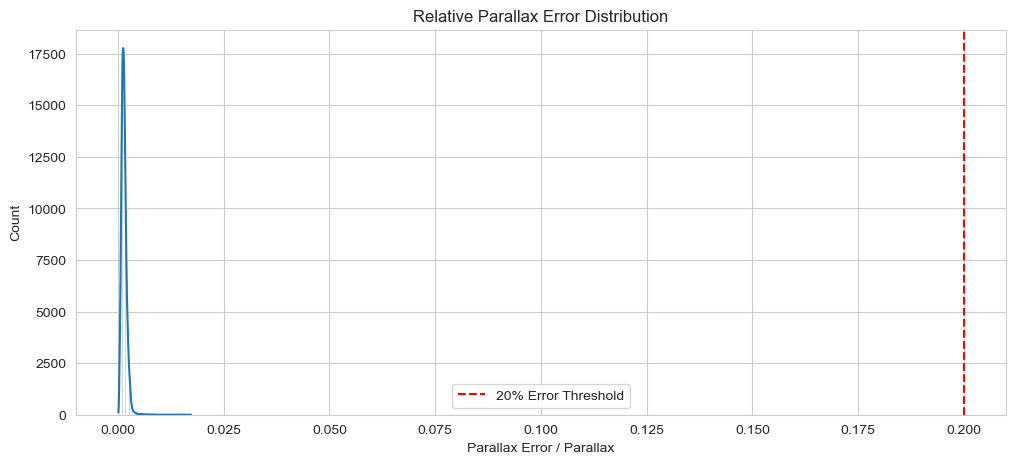

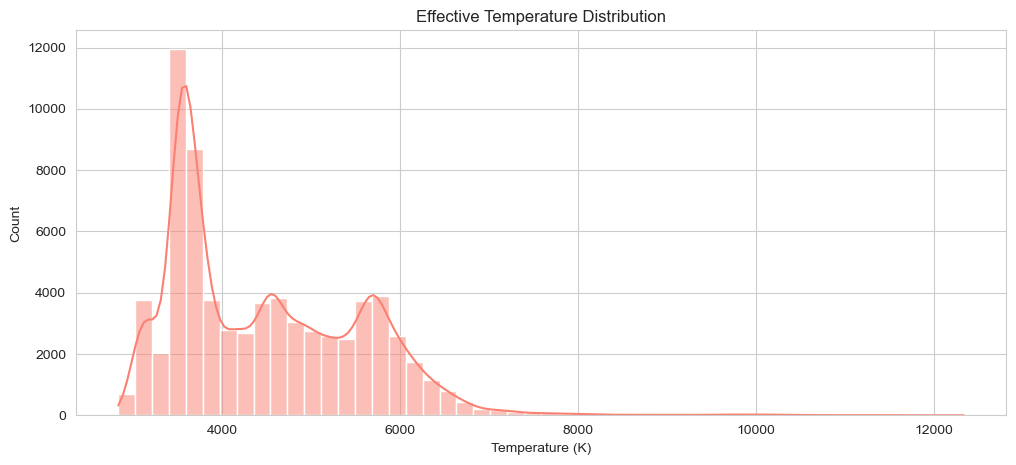

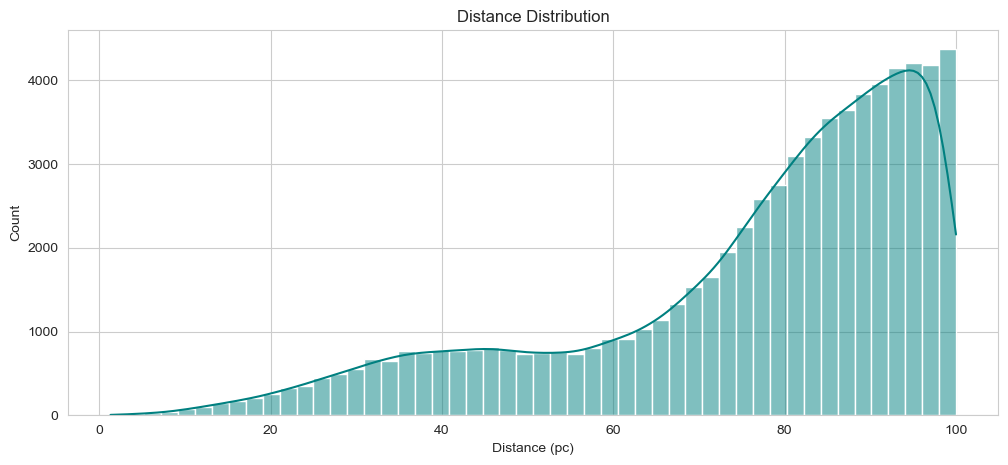

In [9]:
# Plot parallax error distribution
plt.figure(figsize=(12, 5))
sns.histplot(data['parallax_error'] / data['parallax'], bins=50, kde=True)
plt.title('Relative Parallax Error Distribution')
plt.xlabel('Parallax Error / Parallax')
plt.ylabel('Count')
plt.axvline(0.2, color='red', linestyle='--', label='20% Error Threshold')
plt.legend()
plt.show()

# temperature distribution
plt.figure(figsize=(12, 5))
sns.histplot(data['teff_gspphot'], bins=50, kde=True, color='salmon')
plt.title('Effective Temperature Distribution')
plt.xlabel('Temperature (K)')
plt.show()

# distance distribution
plt.figure(figsize=(12, 5))
sns.histplot(data['distance_pc'], bins=50, kde=True, color='teal')
plt.title('Distance Distribution')
plt.xlabel('Distance (pc)')
plt.show()

6. Outlier Detection

In [10]:
# Identify extreme temperatures (adjust thresholds as needed)
valid_teff = (data['teff_gspphot'] > 2500) & (data['teff_gspphot'] < 15000)
data = data[valid_teff]

# Remove stars with unrealistic BP-RP colors
valid_bp_rp = (data['bp_rp'] > -1) & (data['bp_rp'] < 5)
data = data[valid_bp_rp]

print("\nShape after outlier removal:", data.shape)


Shape after outlier removal: (70118, 14)


7. Save Processed Data

In [12]:
data.to_csv('gaia_stars_processed.csv', index=False)
print("Processed data saved!")

Processed data saved!


8. Prilimary H-R Diagram

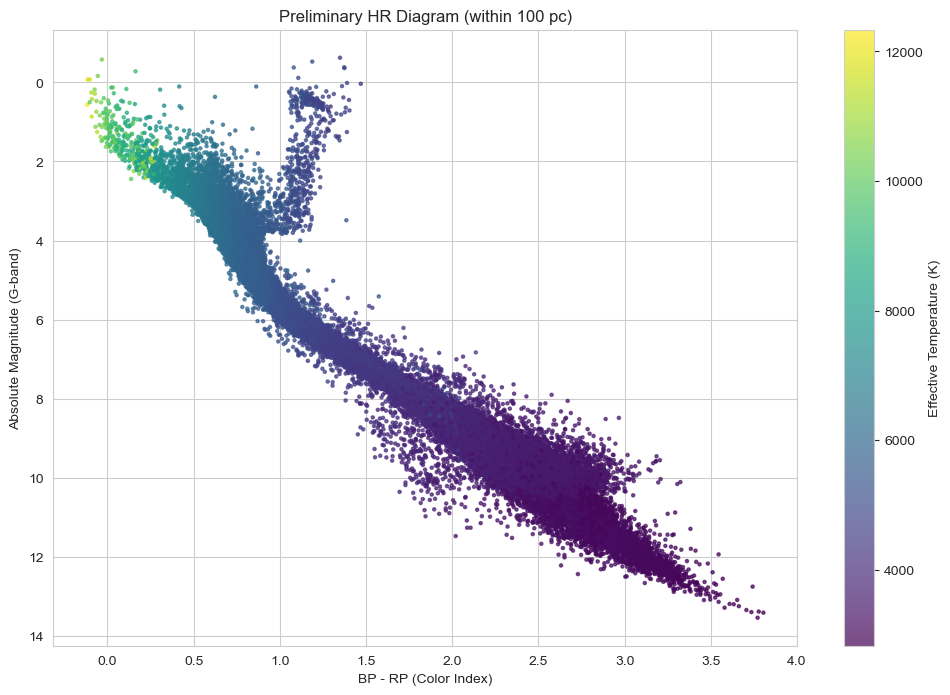

In [13]:
plt.figure(figsize=(12, 8))
plt.scatter( 
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['teff_gspphot'], 
    s=5, 
    alpha=0.7,
    cmap='viridis'
)
plt.colorbar(label='Effective Temperature (K)')
plt.gca().invert_yaxis()  # Brighter stars at the top
plt.xlabel('BP - RP (Color Index)')
plt.ylabel('Absolute Magnitude (G-band)')
plt.title('Preliminary HR Diagram (within 100 pc)')
plt.show()